# JD+ WS Python client demo

In [1]:
import pandas as pd
from pandas import DataFrame

from generator import generate_ts_data
from models import Frequency, Observation, AggregationType, TsData, TsPeriod, DescriptiveStatistics, \
    TemporalDisaggregationResults
from client import CommunicationManager
from datetime import date
import matplotlib.pyplot as plt

In [2]:
communicationManager: CommunicationManager = CommunicationManager()

## Descriptive Statistics

N              160
N Missing      0
Max            1299.0069899270152
Min            5.178926326070399
Average        489.93976692857086
StDev          293.27179187489287
Q25            267.236745451544
Q50            492.1283882427068
Q75            704.6121537686618


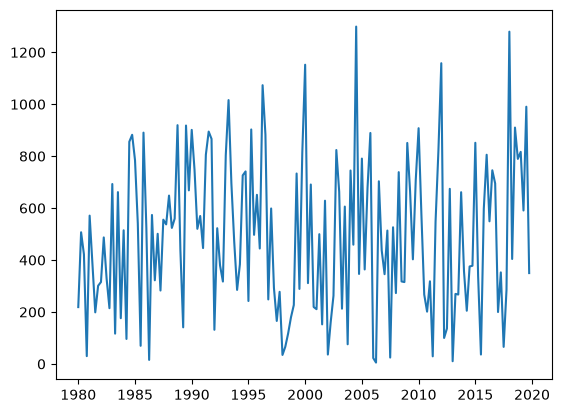

In [3]:
data_descriptive: TsData = generate_ts_data(1980, 0, Frequency.QUARTERLY, 160, True)
plt.plot(*zip(*sorted(data_descriptive.get_date_values().items())), label="Original")

descriptive_statistics: DescriptiveStatistics = communicationManager.get_descriptive_statistics(data_descriptive)
print(descriptive_statistics)

## TS Building

In [9]:
obs: tuple[Observation,...] = (Observation(date=date(2022,1,1),value=1),
                          Observation(date=date(2022,2,1),value=12),
                          Observation(date=date(2023,1,1),value=3),
                          Observation(date=date(2023,2,1),value=5),
                          Observation(date=date(2023,3,1),value=4),
                          Observation(date=date(2022,3,1),value=8),
                          Observation(date=date(2023,4,1),value=12),
                          Observation(date=date(2023,2,1),value=22),
                          Observation(date=date(2021,2,1),value=22))

quarterly_series = communicationManager.build_ts_data(obs, aggregation_type=AggregationType.SUM, frequency=Frequency.QUARTERLY)
yearly_series = communicationManager.build_ts_data(obs, aggregation_type=AggregationType.SUM, frequency=Frequency.YEARLY)

df = pd.concat([quarterly_series.as_dataframe(), yearly_series.as_dataframe()],axis=1)
print(df)


            values  values
2021-01-01    22.0    22.0
2021-04-01     NaN     NaN
2021-07-01     NaN     NaN
2021-10-01     NaN     NaN
2022-01-01    21.0    21.0
2022-04-01     NaN     NaN
2022-07-01     NaN     NaN
2022-10-01     NaN     NaN
2023-01-01    34.0    46.0
2023-04-01    12.0     NaN


## Temporal Disaggregation

In [5]:
# Create series that will be disaggregated
y = TsData(start=TsPeriod(year=1977, position=0, frequency=Frequency.YEARLY),
           values=(500.0,510.0,525.0,520.0))

# Call engine
disaggregated: TemporalDisaggregationResults = communicationManager.process_temporal_disaggregation(y, False, False, "Rw", 12, False, 0, False, 0, False, "SqrtDiffuse", False, 0, 6)

Display disaggregation results

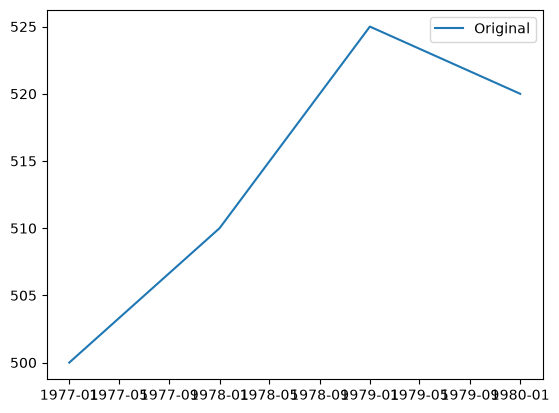

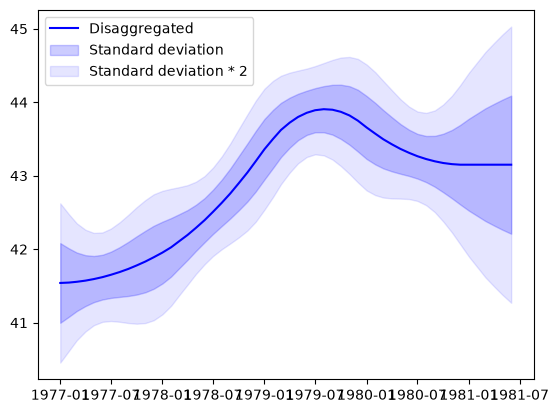

In [6]:
df: DataFrame = disaggregated.as_dataframe()

plt.plot(*zip(*sorted(y.get_date_values().items())), label="Original")
plt.legend()
plt.show()

plt.plot(df.index,df["disaggregated"], color="blue", label="Disaggregated")
plt.fill_between(df.index,df["disaggregated"] - df["stDevDisaggregated"],df["disaggregated"] + df["stDevDisaggregated"], color="blue", alpha=0.2, label="Standard deviation")
plt.fill_between(df.index,df["disaggregated"] - 2 * df["stDevDisaggregated"],df["disaggregated"] + 2 * df["stDevDisaggregated"], color="blue", alpha=0.1, label="Standard deviation * 2")
plt.legend()
plt.show()

In [7]:
print(disaggregated.statistics)

N Obs                    4
N Diffuse                1
N Params                 0
Degrees of freedom       3
Log likelihood           -13.775642324990464
Adjusted log likelihood  -13.775642324990464
AIC                      27.55128464998093
AICC                     27.55128464998093
BIC                      27.55128464998093
SSQ                      0.2948465293959252
LDet                     21.027577909230022
DCorrection              4.969813299576001


In [8]:
print(disaggregated.likelihood)

N Obs                    0
ll                       -13.775642324990464
ssqerr                   0.2948465293959252
ldet                     21.027577909230022
lddet                    0.0
nd                       1
nxd                      0
bvar                     n_rows=0 n_cols=0 values=()
legacy                   False
Scaling factor           True
res                      ()
b                        ()

